# A stiff ODE solved with backward Euler

Companion notebook for Section 7.2 (Stiffness) of `Lec7.tex`. We solve
$$
\frac{du}{dt} = -100\,(u - \sin(t)), \qquad u(0) = 1,
$$
with backward Euler. Since the ODE is linear the implicit update can be solved in closed form:
$$
u_{n+1} = u_n - 100\,\Delta t\,(u_{n+1} - \sin(t_{n+1}))
\quad \Longrightarrow \quad
u_{n+1} = \frac{u_n + 100\,\Delta t \sin(t_{n+1})}{1 + 100\,\Delta t}.
$$
For comparison we also use forward Euler,
$$
u_{n+1} = u_n - 100\,\Delta t\,(u_n - \sin(t_n)),
$$
which is only stable for $\Delta t < 2/100 = 0.02$. We compute:
- backward Euler with a small time step $\Delta t = 10^{-4}$, accurate enough to serve as a reference;
- forward Euler with $\Delta t = 0.005$, small enough to be stable and reasonably accurate;
- backward Euler with the large time step $\Delta t = 0.05$, which is stable but resolves the initial transient poorly.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def backward_euler(u0, T, dt):
    N = int(round(T / dt))
    t = np.linspace(0, N * dt, N + 1)
    u = np.zeros(N + 1)
    u[0] = u0
    for n in range(N):
        u[n + 1] = (u[n] + 100 * dt * np.sin(t[n + 1])) / (1 + 100 * dt)
    return t, u


def forward_euler(u0, T, dt):
    N = int(round(T / dt))
    t = np.linspace(0, N * dt, N + 1)
    u = np.zeros(N + 1)
    u[0] = u0
    for n in range(N):
        u[n + 1] = u[n] - 100 * dt * (u[n] - np.sin(t[n]))
    return t, u

In [38]:
T = 3.0
dt_ref = 1e-2
dt_fe = 8e-3
dt_fe_us = 1.8e-2
dt_be = 0.05

t_ref, u_ref = backward_euler(1.0, T, dt_ref)
t_fe, u_fe = forward_euler(1.0, T, dt_fe)
t_fe_us, u_fe_us = forward_euler(1.0, T, dt_fe_us)
t_be, u_be = backward_euler(1.0, T, dt_be)

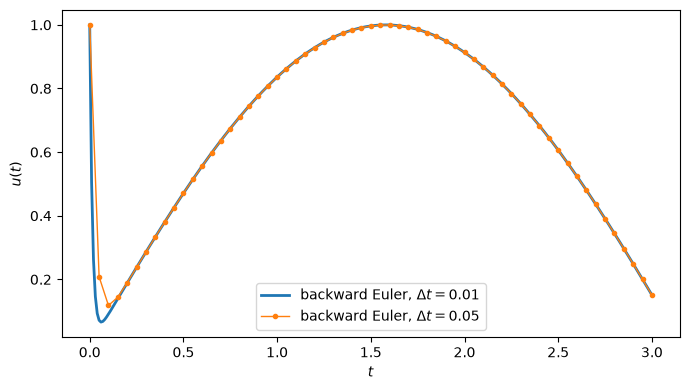

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_ref, u_ref, linewidth=2, label=rf"backward Euler, $\Delta t = {dt_ref:g}$")
ax.plot(t_be, u_be, "o-", markersize=3, linewidth=1, label=rf"backward Euler, $\Delta t = {dt_be:g}$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u(t)$")
ax.legend()
fig.tight_layout()
fig.savefig("stiff_backward_euler.png", dpi=300, bbox_inches="tight")
plt.show()

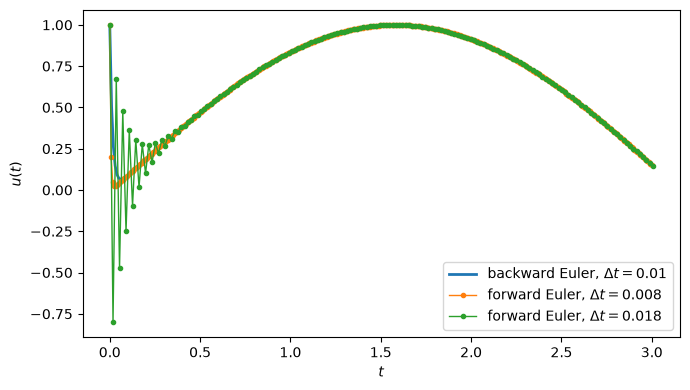

In [41]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_ref, u_ref, linewidth=2, label=rf"backward Euler, $\Delta t = {dt_ref:g}$")
ax.plot(t_fe, u_fe, "o-", linewidth=1, markersize=3, label=rf"forward Euler, $\Delta t = {dt_fe:g}$")
ax.plot(t_fe_us, u_fe_us, "o-", linewidth=1, markersize=3, label=rf"forward Euler, $\Delta t = {dt_fe_us:g}$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u(t)$")
ax.legend()
fig.tight_layout()
fig.savefig("stiff_forward_euler.png", dpi=300, bbox_inches="tight")
plt.show()

The solution decays from $u(0) = 1$ toward $0$ on a fast time scale of order $1/100$, and then follows the slowly
varying sinusoid.
Forward Euler with $\Delta t = 0.005$ tracks the reference solution well. Backward Euler with $\Delta t = 0.05$
cannot resolve the fast initial decay, but it remains stable and captures the slow sinusoidal behavior.